In [9]:
# 1. Import our tools (the libraries)
import pandas as pd
import yfinance as yf
import pandas_datareader as pdr
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

## Data ingestion

In [10]:
# 2. Set time period
start_date = "2010-01-01"
end_date = "2026-01-01"   # exclusive end date, covers 2010-2025

print("Downloading data... please wait!")

# 1. Download daily WTI spot price from FRED/EIA
# DCOILWTICO = Cushing, OK WTI Spot Price FOB, Dollars per Barrel
wti_spot = pdr.DataReader("DCOILWTICO", "fred", start_date, end_date)
wti_spot = wti_spot.rename(columns={"DCOILWTICO": "WTI_Oil"})

# 2. Download daily US Dollar Index from Yahoo Finance
dxy = yf.download(
    "DX-Y.NYB",
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    progress=False
)

# 3. Extract Close price and fix possible MultiIndex columns from yfinance
if isinstance(dxy.columns, pd.MultiIndex):
    usd_index = dxy["Close"].copy()
    usd_index.columns = ["USD_Index"]
else:
    usd_index = dxy[["Close"]].rename(columns={"Close": "USD_Index"})

# 4. Make sure indexes are datetime and timezone-free
wti_spot.index = pd.to_datetime(wti_spot.index).tz_localize(None)
usd_index.index = pd.to_datetime(usd_index.index).tz_localize(None)

# 5. Merge daily WTI spot and USD Index
daily_market = pd.concat([wti_spot, usd_index], axis=1, join="inner")

# 6. Convert daily data to monthly frequency
# Main choice: monthly average
monthly_market = daily_market.resample("MS").mean()

# Alternative: end-of-month value
# monthly_market = daily_market.resample("MS").last()

# 7. Download Federal Funds Effective Rate from FRED
fed_rate = pdr.DataReader("FEDFUNDS", "fred", start_date, end_date)
fed_rate = fed_rate.rename(columns={"FEDFUNDS": "Interest_Rate"})

# Convert FEDFUNDS monthly index to month-start index
fed_rate.index = fed_rate.index.to_period("M").to_timestamp(how="start")

# 8. Merge all variables by month-start index
data = monthly_market.join(fed_rate, how="inner")

# 9. Keep only 2010-2025 if needed
data = data.loc["2010-01-01":"2025-12-01"]

data.head()

,WTI_Oil,USD_Index,Interest_Rate
2010-01-01,78.325789,77.840526,0.11
2010-02-01,76.387368,80.155789,0.13
2010-03-01,81.203478,80.671304,0.16
2010-04-01,84.292857,81.232857,0.20
2010-05-01,73.743500,85.361501,0.20


In [11]:
# 6. Check missing values
full_months = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="MS"
)

missing_months = full_months.difference(data.index)

print("Data shape:", data.shape)
print("Missing months:", len(missing_months))
print(missing_months)

print("\nMissing values by column:")
print(data.isna().sum())

Data shape: (192, 3)
Missing months: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

Missing values by column:
WTI_Oil          0
USD_Index        0
Interest_Rate    0
dtype: int64


In [12]:
# 7. Drop rows only if real missing values remain
final_data = data.dropna()

In [13]:
# 8. Save clean data
final_data.to_csv("../data/oil_usd_interest_data_clean.csv")

final_data.head()

,WTI_Oil,USD_Index,Interest_Rate
2010-01-01,78.325789,77.840526,0.11
2010-02-01,76.387368,80.155789,0.13
2010-03-01,81.203478,80.671304,0.16
2010-04-01,84.292857,81.232857,0.20
2010-05-01,73.743500,85.361501,0.20


In [14]:
# Load the user's data
df = pd.read_csv('../data/oil_usd_interest_data_clean.csv', index_col=0, parse_dates=True)


## EDA:

### Check info of dataframe

In [15]:
df.head()

,WTI_Oil,USD_Index,Interest_Rate
2010-01-01,78.325789,77.840526,0.11
2010-02-01,76.387368,80.155789,0.13
2010-03-01,81.203478,80.671304,0.16
2010-04-01,84.292857,81.232857,0.20
2010-05-01,73.743500,85.361501,0.20


In [16]:
df.shape

(192, 3)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 192 entries, 2010-01-01 to 2025-12-01
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   WTI_Oil        192 non-null    float64
 1   USD_Index      192 non-null    float64
 2   Interest_Rate  192 non-null    float64
dtypes: float64(3)
memory usage: 6.0 KB


In [18]:
df.describe()

,WTI_Oil,USD_Index,Interest_Rate
count,192.000000,192.000000,192.000000
mean,71.615803,92.733106,1.415729
std,20.748657,9.369450,1.814022
min,16.547619,74.236522,0.050000
25%,54.768807,82.448870,0.100000
50%,71.612186,95.231476,0.285000
75%,87.868435,99.025500,2.285000
max,114.837143,111.941428,5.330000


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()


WTI_Oil          0
USD_Index        0
Interest_Rate    0
dtype: int64

In [21]:
# Kiểm tra dữ liệu có thiếu khoảngng thời gian nào không
full_months = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
missing_months = full_months.difference(df.index)
print("Missing months:", len(missing_months))
print(missing_months)

Missing months: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


**The final dataset contains 192 monthly observations from January 2010 to December 2025. The three variables are WTI crude oil price, the U.S. Dollar Index, and the Federal Funds Effective Rate. There are no missing values, duplicated observations, or missing monthly periods, indicating that the dataset is suitable for time-series analysis.**

### Explore data:

In [22]:
print("Minimum WTI:", df["WTI_Oil"].min())
print("Minimum USD Index:", df["USD_Index"].min())

if (df["WTI_Oil"] <= 0).any():
    raise ValueError("WTI_Oil contains non-positive values. Log transformation is not valid.")

if (df["USD_Index"] <= 0).any():
    raise ValueError("USD_Index contains non-positive values. Log transformation is not valid.")

df["Log_WTI"] = np.log(df["WTI_Oil"])
df["Log_USD"] = np.log(df["USD_Index"])

df["D_Log_WTI"] = df["Log_WTI"].diff() * 100
df["D_Log_USD"] = df["Log_USD"].diff() * 100
df["D_Interest_Rate"] = df["Interest_Rate"].diff()

Minimum WTI: 16.547619047619047
Minimum USD Index: 74.23652184527853


INFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 192 entries, 2010-01-01 to 2025-12-01
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   WTI_Oil          192 non-null    float64
 1   USD_Index        192 non-null    float64
 2   Interest_Rate    192 non-null    float64
 3   Log_WTI          192 non-null    float64
 4   Log_USD          192 non-null    float64
 5   D_Log_WTI        191 non-null    float64
 6   D_Log_USD        191 non-null    float64
 7   D_Interest_Rate  191 non-null    float64
dtypes: float64(8)
memory usage: 13.5 KB

HEAD:
              WTI_Oil  USD_Index  Interest_Rate   Log_WTI   Log_USD  \
2010-01-01  78.325789  77.840526           0.11  4.360877  4.354662   
2010-02-01  76.387368  80.155789           0.13  4.335817  4.383972   
2010-03-01  81.203478  80.671304           0.16  4.396958  4.390383   
2010-04-01  84.292857  81.232857           0.20  4.434297  4.397320   
2010-05-

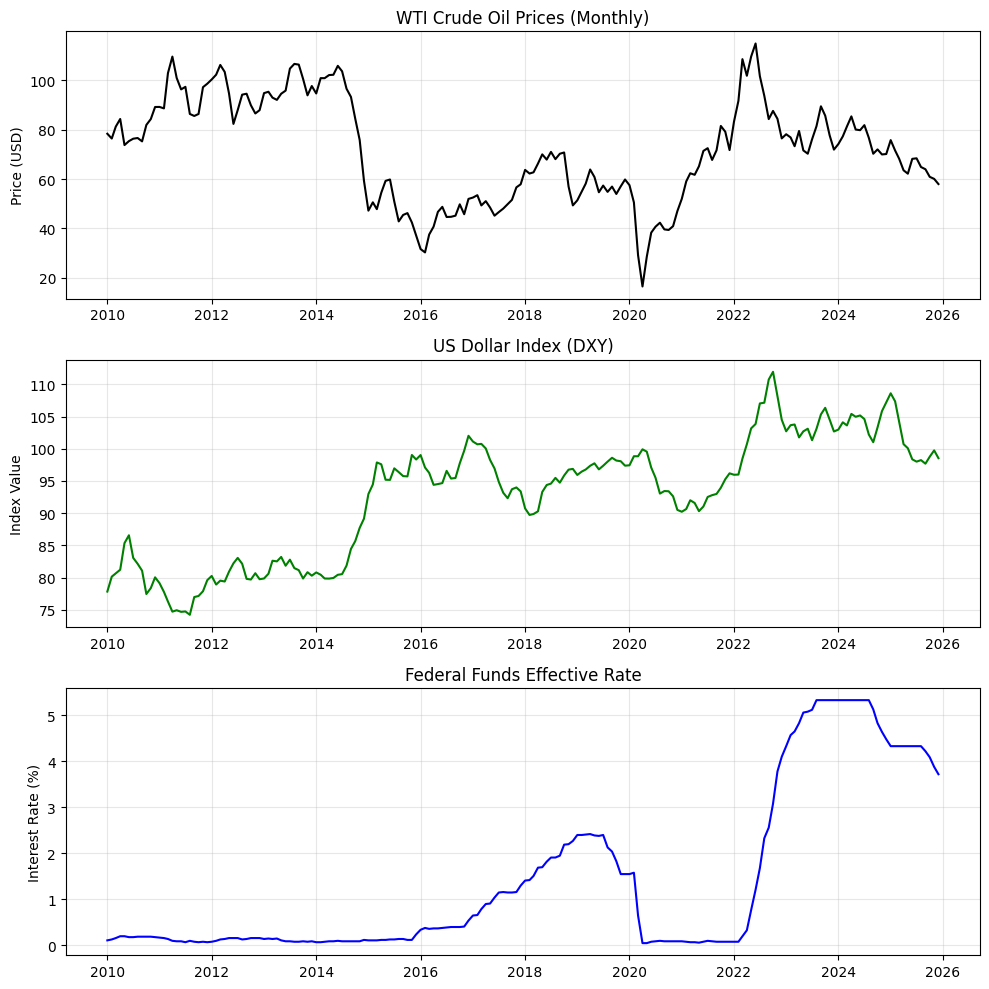

In [23]:
# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].plot(df.index, df['WTI_Oil'], color='black')
axes[0].set_title('WTI Crude Oil Prices (Monthly)')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['USD_Index'], color='green')
axes[1].set_title('US Dollar Index (DXY)')
axes[1].set_ylabel('Index Value')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['Interest_Rate'], color='blue')
axes[2].set_title('Federal Funds Effective Rate')
axes[2].set_ylabel('Interest Rate (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plot.png')

print("INFO:")
df.info()
print("\nHEAD:")
print(df.head())

- **WTI crude oil price**:
    - WTI crude oil prices exhibit several distinct regimes over the sample period. Prices were relatively high during 2010–2013, followed by a sharp decline during 2014–2016. After a moderate recovery in 2017–2019, WTI experienced a severe collapse in April 2020, reaching the lowest point of the sample. Prices then rebounded strongly during 2021–2022 and peaked in mid-2022 before gradually declining toward the end of the sample. This pattern suggests strong structural changes and possible non-stationarity in the WTI series.
- **U.S. Dollar Index**:
    - The U.S. Dollar Index shows an overall upward trend during the sample period. The index was relatively low in the early 2010s, rose sharply around 2014–2015, and reached its highest level in 2022. The simultaneous strengthening of the U.S. dollar and the decline or moderation in WTI prices in several periods is consistent with the expected negative relationship between dollar strength and crude oil prices, although this relationship must be formally tested in the ARDL model.
- **Federal Funds Effective Rate**:
    - The Federal Funds Effective Rate follows clear monetary policy regimes. It remained close to zero during 2010–2015, increased gradually during the 2016–2019 tightening cycle, fell sharply again during the COVID-19 period, and rose rapidly during 2022–2023. This pattern suggests that interest rate movements are highly regime-dependent, which should be considered when interpreting the ARDL results.

### WTI Decomposition:

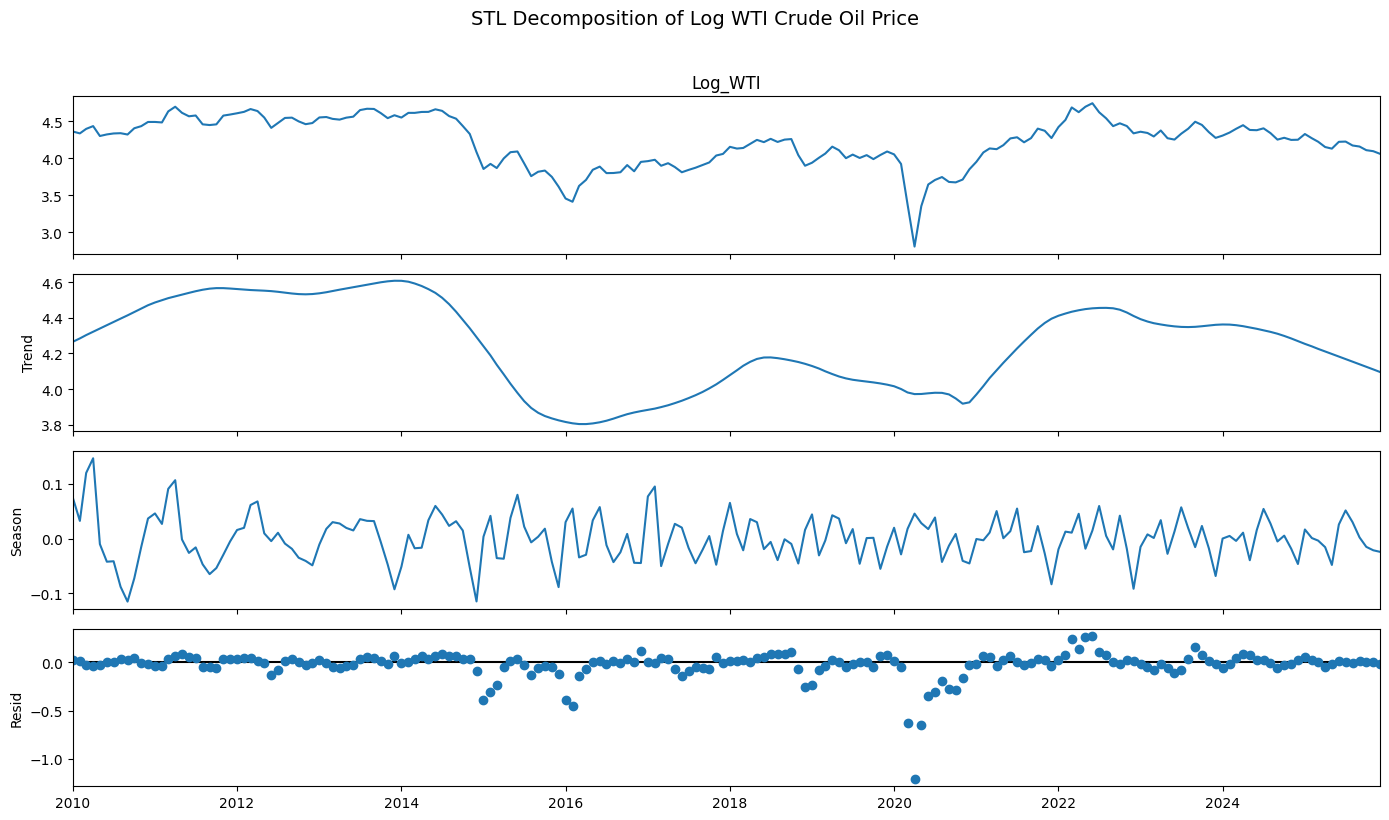

In [24]:
# STL Decomposition for Log WTI
# ================================
df.index = pd.to_datetime(df.index)

# Log transformation
df["Log_WTI"] = np.log(df["WTI_Oil"])

# STL decomposition
# period=12 because the data is monthly
stl = STL(df["Log_WTI"], period=12, robust=True)
stl_result = stl.fit()

# Plot decomposition
fig = stl_result.plot()
fig.set_size_inches(14, 8)
plt.suptitle("STL Decomposition of Log WTI Crude Oil Price", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

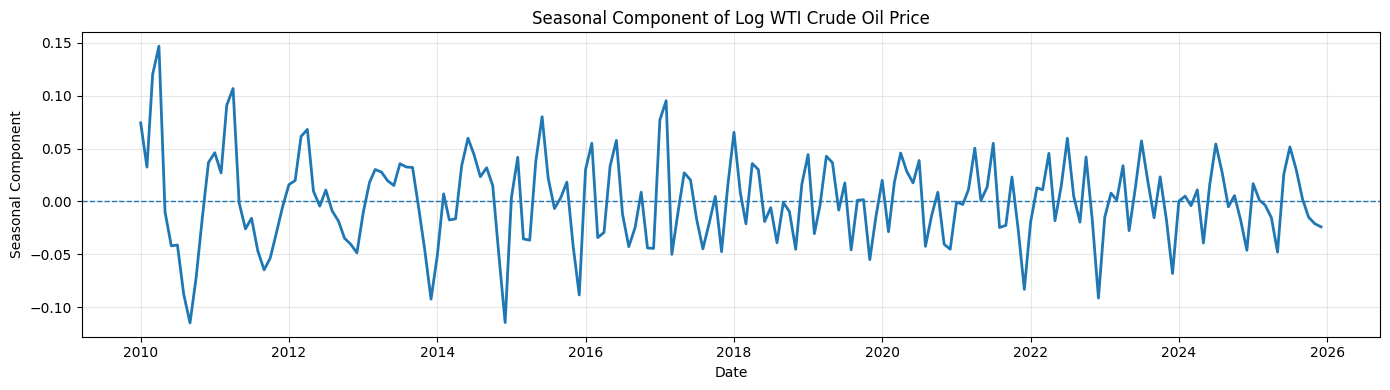

In [25]:
# Extract components
df["WTI_Trend"] = stl_result.trend
df["WTI_Seasonal"] = stl_result.seasonal
df["WTI_Residual"] = stl_result.resid

# Plot seasonal component only
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["WTI_Seasonal"], linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Seasonal Component of Log WTI Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("Seasonal Component")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The STL decomposition of log WTI crude oil prices shows that the series is mainly driven by trend movements and irregular shocks rather than stable seasonal patterns. The trend component captures major oil market regimes, including the 2014–2016 oil price collapse, the COVID-19 shock in 2020, the post-pandemic recovery in 2021–2022, and the gradual decline after 2022. The seasonal component fluctuates around zero and appears relatively small compared with the trend and residual components. This suggests that a non-seasonal ARIMA model can be used as a reasonable baseline, while seasonal extensions such as SARIMA may be considered as a robustness or future extension.**

### Year-over-year changes:

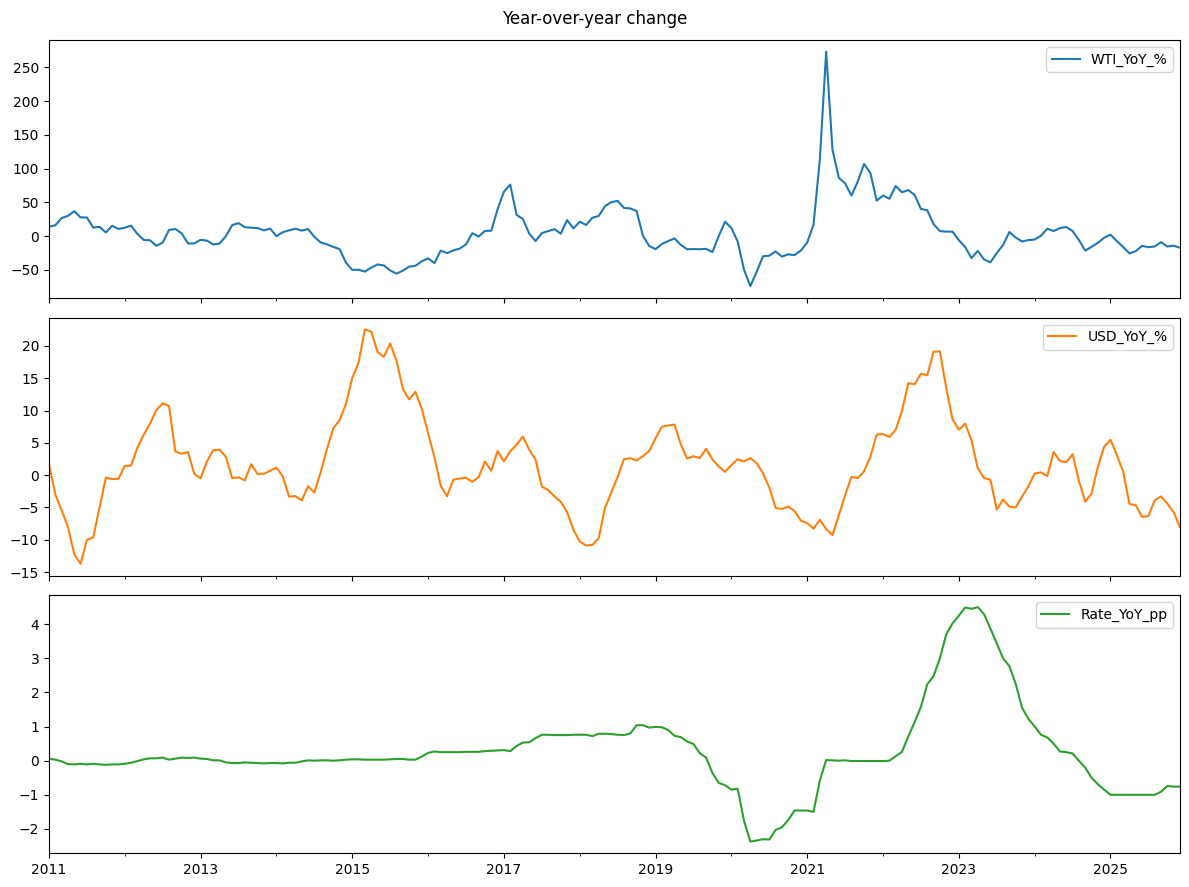

In [26]:
# Year-over-year change
yoy = pd.DataFrame(index=df.index)
yoy["WTI_YoY_%"] = df["WTI_Oil"].pct_change(12) * 100
yoy["USD_YoY_%"] = df["USD_Index"].pct_change(12) * 100
yoy["Rate_YoY_pp"] = df["Interest_Rate"].diff(12)
yoy.dropna().plot(subplots=True, figsize=(12, 9), title="Year-over-year change")
plt.tight_layout()
plt.show()

**The year-over-year changes highlight major shocks in the sample. WTI experienced its largest year-over-year decline during the COVID-19 crisis, followed by an extremely large rebound in 2021. This rebound should be interpreted as a base effect because it compares prices with the unusually low level in April 2020. The U.S. Dollar Index shows strong appreciation during 2014–2015 and 2022, while the interest rate series captures the sharp monetary easing in 2020 and the aggressive tightening cycle during 2022–2023.**

### Normalized Index Plot

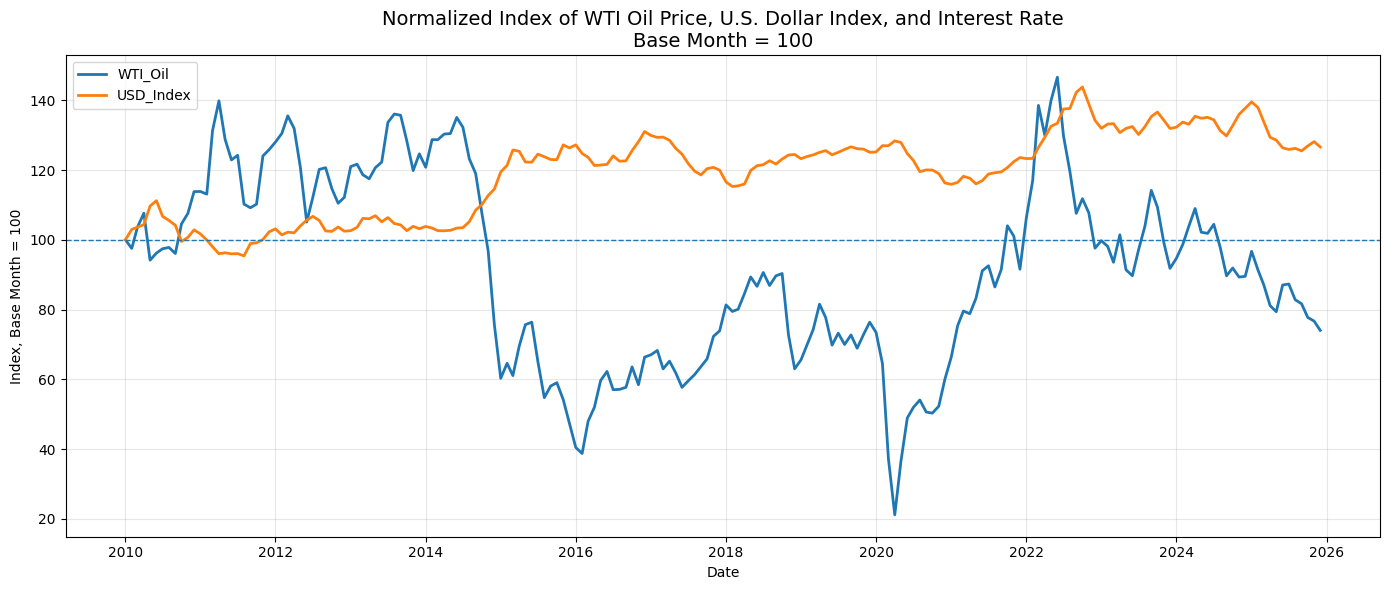

In [27]:
# Normalized Index Plot
# Base period = first observation
# ================================

level_cols = ["WTI_Oil", "USD_Index"]

df_normalized = df[level_cols].copy()

# Normalize each series: first month = 100
df_normalized = df_normalized / df_normalized.iloc[0] * 100

plt.figure(figsize=(14, 6))

for col in df_normalized.columns:
    plt.plot(df_normalized.index, df_normalized[col], label=col, linewidth=2)

plt.axhline(y=100, linestyle="--", linewidth=1)
plt.title("Normalized Index of WTI Oil Price, U.S. Dollar Index, and Interest Rate\nBase Month = 100", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Index, Base Month = 100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The normalized index plot compares the relative movements of WTI crude oil prices and the U.S. Dollar Index using the first month of the sample as the base period. WTI prices display substantially higher volatility than the U.S. Dollar Index. The sharp decline in WTI during 2014–2016 occurred alongside a strong appreciation of the U.S. dollar, which is consistent with the expected negative relationship between oil prices and dollar strength. During 2021–2022, WTI prices recovered sharply, while the U.S. Dollar Index also strengthened, suggesting that the relationship may vary across periods and should be examined using a dynamic model such as ARDL rather than simple correlation alone.**

### Histogram and Boxplot for Level Variables

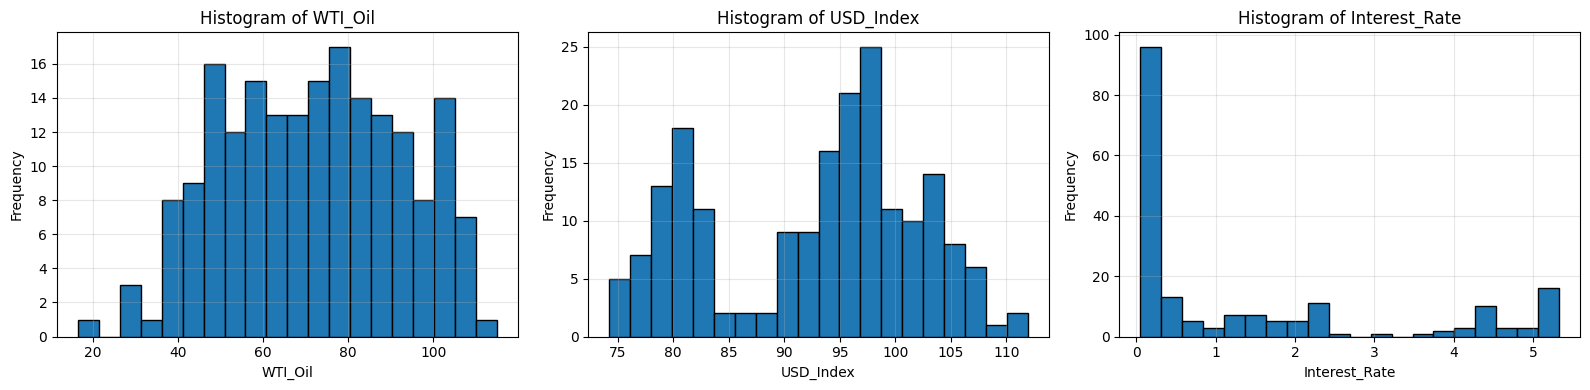

In [28]:
# ================================
# Histogram of level variables
# ================================

level_cols = ["WTI_Oil", "USD_Index", "Interest_Rate"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, level_cols):
    ax.hist(df[col].dropna(), bins=20, edgecolor="black")
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

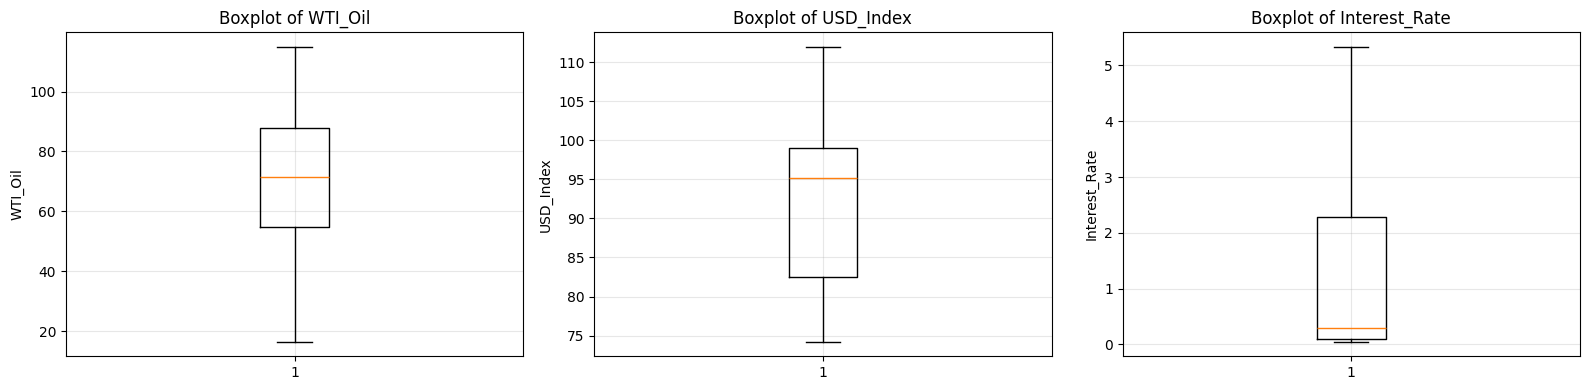

In [29]:
# ================================
# Boxplot of level variables
# ================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, level_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**- WTI crude oil prices: The distribution of WTI crude oil prices is widely dispersed, reflecting the high volatility of oil markets. The lower tail is associated with the COVID-19 oil price collapse, while the upper values correspond to high-price periods such as the early 2010s and the 2021–2022 recovery. These extreme observations represent genuine market events and should be retained in the analysis.** 

**- U.S. Dollar Index: The U.S. Dollar Index shows a clustered distribution, indicating different exchange-rate regimes over the sample period. The index was relatively low in the early 2010s and shifted to higher levels after the mid-2010s, especially during the 2022 tightening period** 

**- Interest Rate: The interest rate distribution is highly right-skewed, with many observations close to zero and fewer observations at high interest rate levels. This reflects distinct monetary policy regimes, including the near-zero interest rate period after the global financial crisis and COVID-19, followed by the aggressive tightening cycle after 2022.**

### Histogram and Boxplot for Log-Difference / Difference Variables

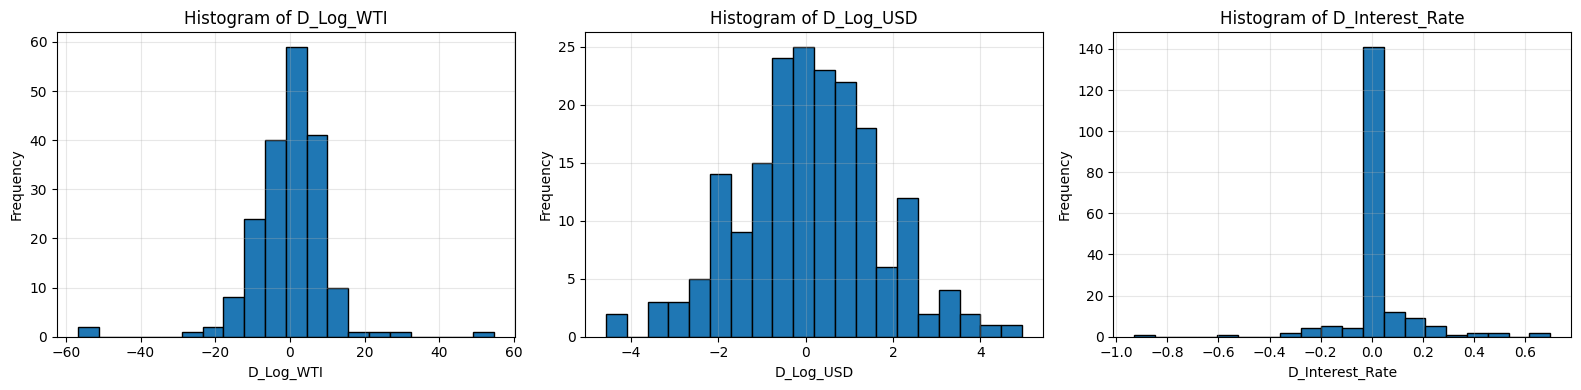

In [30]:
# ================================
# Histogram of transformed variables
# ================================

diff_cols = ["D_Log_WTI", "D_Log_USD", "D_Interest_Rate"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, diff_cols):
    ax.hist(df[col].dropna(), bins=20, edgecolor="black")
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

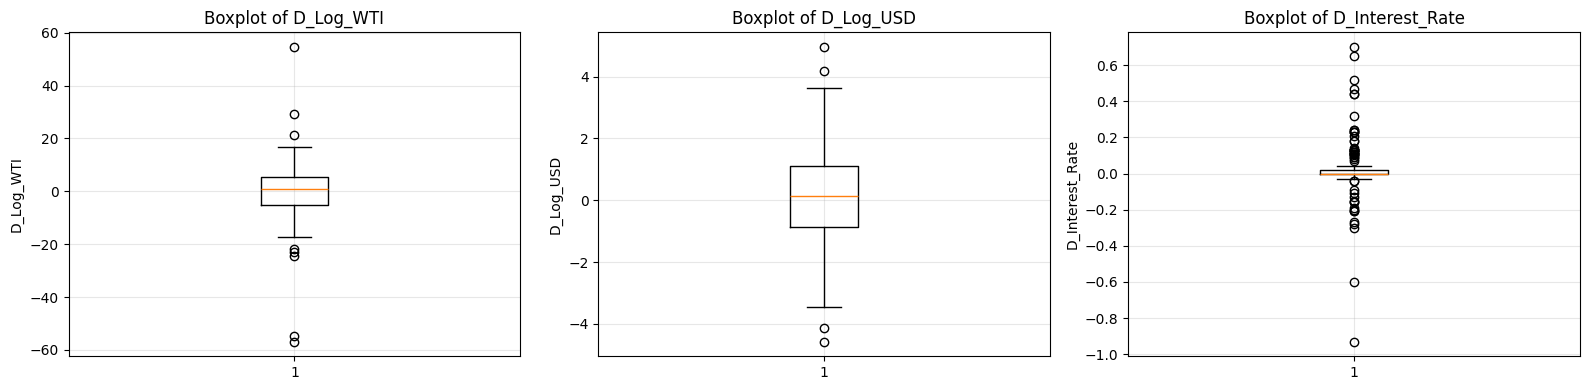

In [31]:
# ================================
# Boxplot of transformed variables
# ================================

diff_cols = ["D_Log_WTI", "D_Log_USD", "D_Interest_Rate"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, diff_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**- D_Log_WTI: Monthly log changes in WTI prices are centered around zero but display fat tails and extreme observations. This indicates that WTI prices experience large short-run shocks, especially during crisis periods. The presence of extreme changes suggests that ARIMA residual diagnostics should be checked carefully after model estimation.** 

**- D_Log_USD_Index: Monthly log changes in the U.S. Dollar Index are less volatile than WTI changes. This suggests that exchange rate movements are smoother than crude oil price movements at the monthly frequency.** 

**- D_Interest_Rate: Changes in the interest rate are concentrated around zero, reflecting periods of stable monetary policy. However, several large positive and negative changes are observed, corresponding to rapid policy tightening or easing episodes.**


### Rolling Volatility của WTI

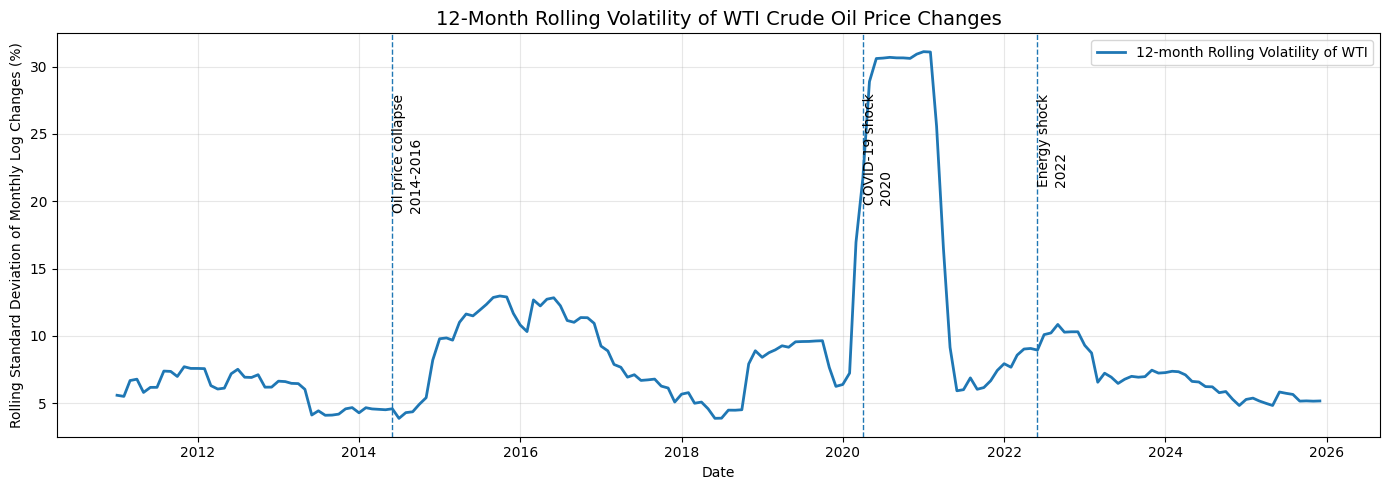

In [32]:
# ================================
# Rolling volatility with crisis markers
# ================================
df["WTI_Rolling_Vol_12M"] = df["D_Log_WTI"].rolling(window=12).std()
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["WTI_Rolling_Vol_12M"],
    linewidth=2,
    label="12-month Rolling Volatility of WTI"
)

# Add important event markers
event_dates = {
    "Oil price collapse\n2014-2016": "2014-06-01",
    "COVID-19 shock\n2020": "2020-04-01",
    "Energy shock\n2022": "2022-06-01"
}

for label, date in event_dates.items():
    plt.axvline(pd.to_datetime(date), linestyle="--", linewidth=1)
    plt.text(
        pd.to_datetime(date),
        df["WTI_Rolling_Vol_12M"].max() * 0.9,
        label,
        rotation=90,
        verticalalignment="top"
    )

plt.title("12-Month Rolling Volatility of WTI Crude Oil Price Changes", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation of Monthly Log Changes (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The 12-month rolling volatility of WTI crude oil price changes shows substantial time variation. Volatility increased during the 2014–2016 oil price collapse, reached its highest level during the COVID-19 shock in 2020, and rose again around the 2022 energy shock. This confirms that WTI prices are subject to large and time-varying shocks. Although the current study focuses on ARIMA and ARDL, this finding suggests that volatility models such as GARCH could be considered in future research.**

### Lag Correlation

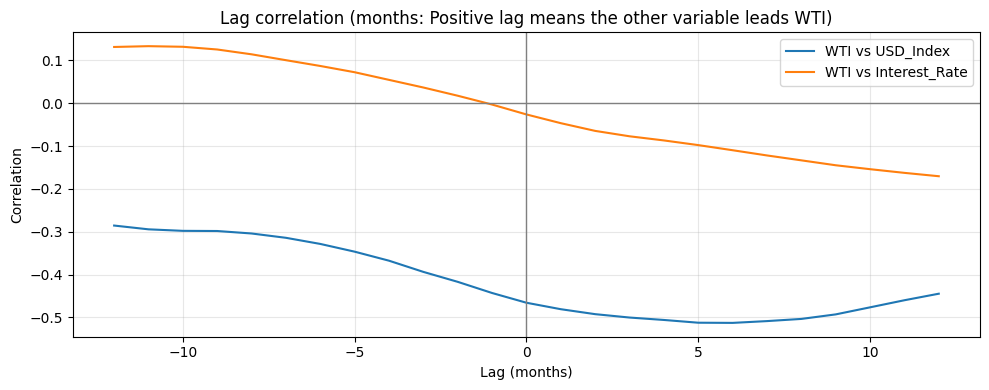

In [33]:
# Lag correlation (WTI vs other series)
lags = range(-12, 13)

def lag_corr(a, b):
    return pd.Series({lag: a.corr(b.shift(lag)) for lag in lags})

lag_usd = lag_corr(df["WTI_Oil"], df["USD_Index"])
lag_rate = lag_corr(df["WTI_Oil"], df["Interest_Rate"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag_usd.index, lag_usd.values, label="WTI vs USD_Index")
ax.plot(lag_rate.index, lag_rate.values, label="WTI vs Interest_Rate")
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Lag correlation (months: Positive lag means the other variable leads WTI)")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Correlation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The lag correlation plot shows that the relationship between WTI and the U.S. Dollar Index remains negative across most lags, with stronger negative correlations at several positive lags. This may suggest a potential lead-lag relationship from the U.S. Dollar Index to WTI prices. However, because the calculation is based on level variables, the result should be interpreted cautiously due to possible non-stationarity. A more reliable lead-lag analysis should also be performed using log-differenced or stationary variables.**

### Rolling Correlation between WTI and U.S. Dollar Index, Interest Rate

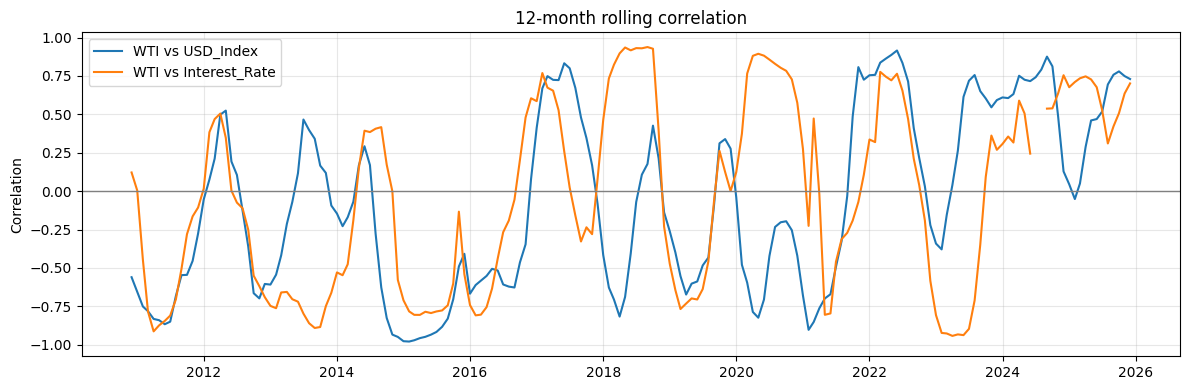

In [34]:
# Rolling correlation
window = 12
rolling_corr_usd = df["WTI_Oil"].rolling(window).corr(df["USD_Index"])
rolling_corr_rate = df["WTI_Oil"].rolling(window).corr(df["Interest_Rate"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, rolling_corr_usd, label="WTI vs USD_Index")
ax.plot(df.index, rolling_corr_rate, label="WTI vs Interest_Rate")
ax.axhline(0, color="gray", linewidth=1)
ax.set_title(f"{window}-month rolling correlation")
ax.set_ylabel("Correlation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The 12-month rolling correlations indicate that the relationships between WTI prices, the U.S. Dollar Index, and the interest rate are time-varying. The sign and magnitude of the correlations change substantially across subperiods, suggesting that the relationship is not stable over the full sample. This supports the use of a dynamic time-series framework such as ARDL, which can distinguish between short-run adjustments and long-run relationships.**

### Summary of Period

In [35]:
# Summary by period
cols = ["WTI_Oil", "USD_Index", "Interest_Rate"]
periods = {
    "2010-2013": ("2010-01-01", "2013-12-01"),
    "2014-2016": ("2014-01-01", "2016-12-01"),
    "2017-2019": ("2017-01-01", "2019-12-01"),
    "2020-2021": ("2020-01-01", "2021-12-01"),
    "2022-2025": ("2022-01-01", "2025-12-01")
}

summary_rows = []
for name, (start, end) in periods.items():
    subset = df.loc[start:end, cols]
    stats = subset.agg(["mean", "std", "min", "max"]).T
    stats["period"] = name
    summary_rows.append(stats)

period_summary = pd.concat(summary_rows).reset_index().rename(columns={"index": "variable"})
period_summary

,variable,mean,std,min,max,period
0,WTI_Oil,91.579538,9.561319,73.743500,109.532500,2010-2013
1,USD_Index,79.913798,2.720630,74.236522,86.575000,2010-2013
2,Interest_Rate,0.131042,0.041424,0.070000,0.200000,2010-2013
3,WTI_Oil,61.700475,24.617684,30.323000,105.794286,2014-2016
4,USD_Index,91.919628,7.157076,79.853334,102.013333,2014-2016
5,Interest_Rate,0.205556,0.141451,0.070000,0.540000,2014-2016
6,WTI_Oil,57.595814,7.445851,45.177727,70.981429,2017-2019
7,USD_Index,95.849989,2.991889,89.730526,101.122000,2017-2019
8,Interest_Rate,1.663889,0.567900,0.650000,2.420000,2017-2019
9,WTI_Oil,53.607453,17.458893,16.547619,81.476667,2020-2021


**The period-based summary confirms the regime patterns observed in the time-series plots. WTI prices were highest on average during 2010–2013, declined sharply during 2014–2016, and reached their lowest point during the COVID-19 period. The 2022–2025 period is characterized by a recovery in WTI prices, a historically strong U.S. dollar, and substantially higher interest rates. These regime differences suggest that crude oil prices are affected by changing macro-financial conditions over time.**

### Correlation Matrix

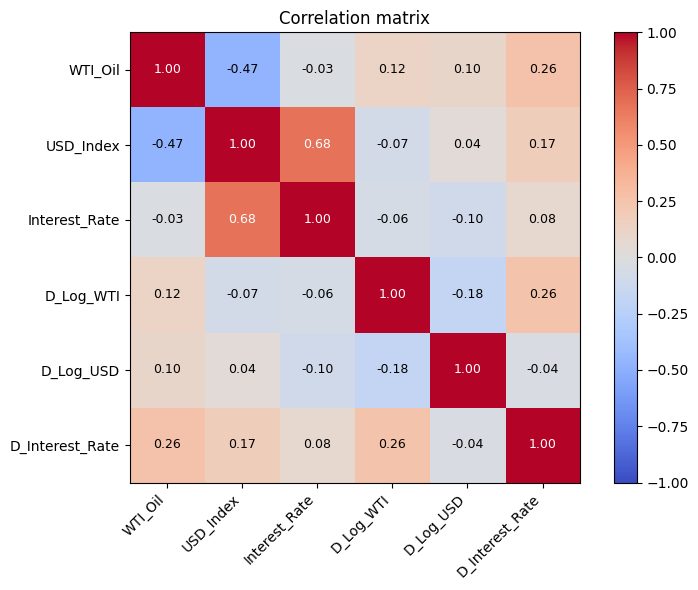

In [36]:
# Correlation matrix
cols = ["WTI_Oil", "USD_Index", "Interest_Rate", "D_Log_WTI", "D_Log_USD", "D_Interest_Rate"]
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# Add correlation values to each cell
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        text_color = "white" if abs(value) >= 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=9)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

**The correlation analysis shows a moderate negative relationship between WTI prices and the U.S. Dollar Index in levels. However, after using log-differenced variables, the correlation becomes weaker. This suggests that part of the level correlation may reflect common trends or regime shifts rather than a stable short-run relationship. Therefore, correlation analysis should be interpreted as descriptive evidence only, while formal inference will be conducted using ARDL.**

### Check stationarity

In [37]:
# Kiểm định tính dừng: ADF/KPSS hoặc ADF/PP cho Log_WTI, Log_USD, Interest_Rate.
for col in cols:
    print(f"Testing stationarity for {col}...")
    # ADF test
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(df[col].dropna())
    print(f"ADF p-value: {adf_result[1]:.4f}")
    
    # KPSS test
    from statsmodels.tsa.stattools import kpss
    kpss_result = kpss(df[col].dropna(), regression='c')
    print(f"KPSS p-value: {kpss_result[1]:.4f}")
    
    # PP test
    from arch.unitroot import PhillipsPerron
    pp_result = PhillipsPerron(df[col].dropna())
    # Hàm này trả về một object, ta lấy p-value bằng .pvalue
    print(f"PP p-value: {pp_result.pvalue:.4f}")
    
    print("-" * 40)

Testing stationarity for WTI_Oil...
ADF p-value: 0.2268
KPSS p-value: 0.0729
PP p-value: 0.2392
----------------------------------------
Testing stationarity for USD_Index...
ADF p-value: 0.4060
KPSS p-value: 0.0100
PP p-value: 0.4208
----------------------------------------
Testing stationarity for Interest_Rate...
ADF p-value: 0.2111
KPSS p-value: 0.0100
PP p-value: 0.6681
----------------------------------------
Testing stationarity for D_Log_WTI...
ADF p-value: 0.0000
KPSS p-value: 0.1000
PP p-value: 0.0000
----------------------------------------
Testing stationarity for D_Log_USD...
ADF p-value: 0.0000
KPSS p-value: 0.1000
PP p-value: 0.0000
----------------------------------------
Testing stationarity for D_Interest_Rate...
ADF p-value: 0.0499
KPSS p-value: 0.1000
PP p-value: 0.0000
----------------------------------------


C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\1268677776.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')
C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\1268677776.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')
C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\1268677776.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')
C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\1268677776.py:11: InterpolationWarning: The test statistic is outside of the range of p-

**The level variables are generally treated as non-stationary based mainly on ADF and Phillips-Perron results, while KPSS results should be interpreted with caution.**

**We will check stationarity after get log transformed data**

In [38]:
# Kiểm định tính dừng: ADF/KPSS hoặc ADF/PP cho Log_WTI, Log_USD, Interest_Rate.
cols = ["Log_WTI", "Log_USD", "Interest_Rate"]
for col in cols:
    print(f"Testing stationarity for {col}...")
    # ADF test
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(df[col].dropna())
    print(f"ADF p-value: {adf_result[1]:.4f}")
    
    # KPSS test
    from statsmodels.tsa.stattools import kpss
    kpss_result = kpss(df[col].dropna(), regression='c')
    print(f"KPSS p-value: {kpss_result[1]:.4f}")
    
    # PP test
    from arch.unitroot import PhillipsPerron
    pp_result = PhillipsPerron(df[col].dropna())
    # Hàm này trả về một object, ta lấy p-value bằng .pvalue
    print(f"PP p-value: {pp_result.pvalue:.4f}")
    
    print("-" * 40)

Testing stationarity for Log_WTI...
ADF p-value: 0.1615
KPSS p-value: 0.0927
PP p-value: 0.1521
----------------------------------------
Testing stationarity for Log_USD...
ADF p-value: 0.4397
KPSS p-value: 0.0100
PP p-value: 0.4165
----------------------------------------
Testing stationarity for Interest_Rate...
ADF p-value: 0.2111
KPSS p-value: 0.0100
PP p-value: 0.6681
----------------------------------------


C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\2169489963.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')
C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\2169489963.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')


**The result is all features are non-stationary, we will check stationarity after differencing**

In [39]:
# Kiểm định tính dừng: ADF/KPSS hoặc ADF/PP cho các biến sai phân
cols_diff = ["D_Log_WTI", "D_Log_USD", "D_Interest_Rate"]
for col in cols_diff:
    print(f"Testing stationarity for {col}...")
    # ADF test
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(df[col].dropna())
    print(f"ADF p-value: {adf_result[1]:.4f}")
    
    # KPSS test
    from statsmodels.tsa.stattools import kpss
    kpss_result = kpss(df[col].dropna(), regression='c')
    print(f"KPSS p-value: {kpss_result[1]:.4f}")
    
    # PP test
    from arch.unitroot import PhillipsPerron
    pp_result = PhillipsPerron(df[col].dropna())
    print(f"PP p-value: {pp_result.pvalue:.4f}")
    
    print("-" * 40)

Testing stationarity for D_Log_WTI...
ADF p-value: 0.0000
KPSS p-value: 0.1000
PP p-value: 0.0000
----------------------------------------
Testing stationarity for D_Log_USD...
ADF p-value: 0.0000
KPSS p-value: 0.1000
PP p-value: 0.0000
----------------------------------------
Testing stationarity for D_Interest_Rate...
ADF p-value: 0.0499
KPSS p-value: 0.1000
PP p-value: 0.0000
----------------------------------------


C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\3209741515.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')
C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\3209741515.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')
C:\Users\ACER\AppData\Local\Temp\ipykernel_6380\3209741515.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df[col].dropna(), regression='c')


**Features are all stationary after first order differencing**

**The EDA results show that WTI crude oil prices exhibit strong trend movements, regime shifts, large shocks, and time-varying volatility. The correlation analysis also suggests a potential negative relationship between WTI prices and the U.S. Dollar Index, while the role of interest rates appears less clear from simple correlations. Since visual inspection and decomposition indicate possible non-stationarity, the next step is to conduct formal unit root tests before estimating ARIMA and ARDL models. ARIMA will be used as a univariate forecasting model for WTI prices, while ARDL will be used to examine the short-run and long-run roles of the U.S. Dollar Index and interest rate.**